# Module M3.1 — Preprocessing Pipeline Construction

**Project:** Explainable and Bias-Aware ML for Phishing Website Detection  
**Roadmap ref:** Phase 3 → Module M3.1  

### Pipeline steps (in order)
1. Feature Engineering (7 derived columns)  
2. TLD Frequency Encoding (string → integer rank, top-50)  
3. Outlier Clipping (P99.9 per feature — train-only fit)  
4. Log1p Transform (15 skewed count features)  
5. RobustScaler (continuous non-binary features)  

### Expected outputs
- Track A: **57 features**  
- Track B: **56 features**  


## 0. Environment Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')


Project root: C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from src.utils.logger              import get_logger
from src.features.feature_catalog  import get_feature_lists
from src.features.encoding         import TLDFrequencyEncoder, build_tld_encoding_report
from src.features.preprocessing    import (
    OutlierClipper, Log1pTransformer, RobustScalerTransformer,
    LOG1P_FEATURES, BINARY_FEATURES,
)
from src.features.engineering      import FeatureEngineer, ENGINEERED_FEATURE_NAMES
from src.features.validation       import run_full_validation
from src.features.pipeline_builder import (
    build_pipeline, fit_pipeline, transform_data,
    save_pipeline, load_pipeline, run_full_preprocessing,
)
from src.data.splitter             import run_split_pipeline

logger = get_logger('notebook.04_preprocessing')
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
print('Imports OK ✓')


Imports OK ✓


## 1. Path Configuration

In [3]:
CLEAN_CSV       = PROJECT_ROOT / 'data' / 'processed' / 'clean_df.csv'
PROCESSED_DIR   = PROJECT_ROOT / 'data' / 'processed'
PREPROCESSOR_DIR= PROJECT_ROOT / 'outputs' / 'preprocessors'
REPORTS_DIR     = PROJECT_ROOT / 'outputs' / 'reports'
PLOTS_DIR       = PROJECT_ROOT / 'outputs' / 'plots' / 'eda'

assert CLEAN_CSV.exists(), f'Run M1.1 first: {CLEAN_CSV}'
PREPROCESSOR_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
print('Paths OK ✓')


Paths OK ✓


## 2. Data Loading

In [4]:
df = pd.read_csv(CLEAN_CSV, low_memory=False)
fl = get_feature_lists()

print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'Track A base features: {len(fl.track_A)}')
print(f'Track B base features: {len(fl.track_B)}')


Loaded: 235,370 rows × 56 cols
Track A base features: 50
Track B base features: 49


## 3. Stratified 80/20 Train/Test Split

In [5]:
split_results = run_split_pipeline(
    df            = df,
    track_A_feats = fl.track_A,
    track_B_feats = fl.track_B,
    output_dir    = PROCESSED_DIR,
)

print(f"Train: {split_results['n_train']:,}  Test: {split_results['n_test']:,}")

X_A_train_raw = split_results['track_A_train'].drop(columns=['label'], errors='ignore')
X_A_test_raw  = split_results['track_A_test'].drop(columns=['label'],  errors='ignore')
X_B_train_raw = split_results['track_B_train'].drop(columns=['label'], errors='ignore')
X_B_test_raw  = split_results['track_B_test'].drop(columns=['label'],  errors='ignore')
y_train       = split_results['y_train']
y_test        = split_results['y_test']

print(f'X_A_train: {X_A_train_raw.shape}  X_A_test: {X_A_test_raw.shape}')
print(f'X_B_train: {X_B_train_raw.shape}  X_B_test: {X_B_test_raw.shape}')


2026-06-17 20:26:51 | INFO     | src.data.splitter                        | =======================================================
2026-06-17 20:26:51 | INFO     | src.data.splitter                        | M3.1 — STRATIFIED TRAIN/TEST SPLIT
2026-06-17 20:26:51 | INFO     | src.data.splitter                        | =======================================================
2026-06-17 20:26:51 | INFO     | src.data.splitter                        | Stratified split: 188,296 train / 47,074 test (test_size=0.2, seed=42)
2026-06-17 20:26:51 | INFO     | src.data.splitter                        |   Phishing % — original: 42.71%  train: 42.71%  test: 42.71%
2026-06-17 20:26:51 | INFO     | src.data.splitter                        | Class balance PASSED ✓
2026-06-17 20:26:51 | INFO     | src.data.splitter                        | Saved y_train.csv (188,296)  y_test.csv (47,074)
2026-06-17 20:26:54 | INFO     | src.data.splitter                        | Saved → raw_X_train.csv  (188,296 rows)  

Train: 188,296  Test: 47,074
X_A_train: (188296, 50)  X_A_test: (47074, 50)
X_B_train: (188296, 49)  X_B_test: (47074, 49)


## 4. Phase A — TLD Frequency Encoding

In [6]:
# Demonstrate TLD encoding in isolation
tld_enc = TLDFrequencyEncoder(top_n=50)
tld_enc.fit(X_B_train_raw)

tld_report = build_tld_encoding_report(tld_enc)
tld_report.to_csv(REPORTS_DIR / 'tld_encoding_report.csv', index=False)

print(f'Top-50 TLDs preserved, {tld_enc.rare_rank_} = rare_tld rank')
print(f'\nTop 10 TLDs:')
display(tld_report.head(10))


2026-06-17 20:26:58 | INFO     | src.features.encoding                    | TLDFrequencyEncoder fitted: 661 unique TLDs → top-50 preserved, 611 bucketed as rare_tld (rank=51)
2026-06-17 20:26:58 | INFO     | src.features.encoding                    | TLD encoding report: 50 top TLDs + 1 rare bucket


Top-50 TLDs preserved, 51 = rare_tld rank

Top 10 TLDs:


,tld,frequency,rank,bucket
0,com,89832,1,top_tld
1,org,15059,2,top_tld
2,net,5727,3,top_tld
3,app,5196,4,top_tld
4,uk,5128,5,top_tld
5,co,4295,6,top_tld
6,io,3330,7,top_tld
7,de,3209,8,top_tld
8,ru,3078,9,top_tld
9,au,2417,10,top_tld


findfont: Failed to find font weight 600, now using 700.


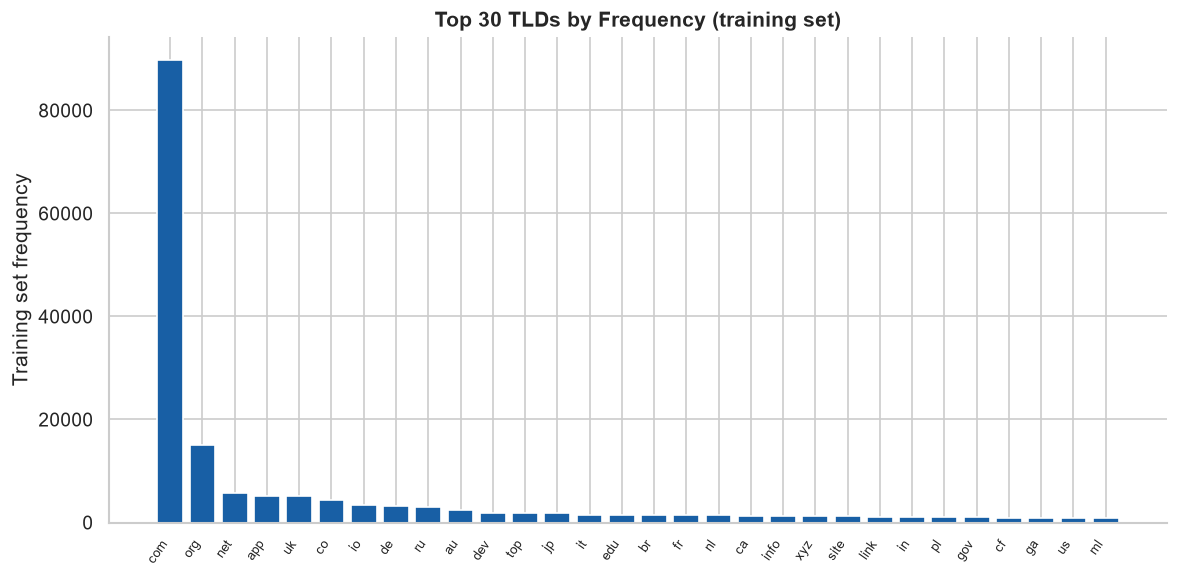

In [7]:
# Visualise TLD rank distribution
top30 = tld_report[tld_report['bucket']=='top_tld'].head(30)
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(top30)), top30['frequency'], color='#185FA5', edgecolor='white')
ax.set_xticks(range(len(top30)))
ax.set_xticklabels(top30['tld'], rotation=55, ha='right', fontsize=8)
ax.set_ylabel('Training set frequency')
ax.set_title('Top 30 TLDs by Frequency (training set)', fontweight='600')
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'tld_encoding_frequency.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Phase B — Skewness Correction (Log1p)

In [8]:
# Show before/after skewness for log1p features
valid_log_feats = [f for f in LOG1P_FEATURES if f in X_B_train_raw.columns]

skew_before = X_B_train_raw[valid_log_feats].skew().abs().sort_values(ascending=False)
X_logged    = X_B_train_raw[valid_log_feats].clip(lower=0).apply(np.log1p)
skew_after  = X_logged.skew().abs().sort_values(ascending=False)

skew_report = pd.DataFrame({
    'feature'       : valid_log_feats,
    'skewness_before': [round(X_B_train_raw[f].skew(), 4) for f in valid_log_feats],
    'skewness_after' : [round(X_logged[f].skew(), 4) for f in valid_log_feats],
}).assign(reduction_pct=lambda d: (
    (1 - d['skewness_after'].abs() / d['skewness_before'].abs().replace(0, 1e-9)) * 100
).round(2))

skew_report.to_csv(REPORTS_DIR / 'skewness_correction_report.csv', index=False)
print('Top 10 skewness reductions:')
display(skew_report.nlargest(10, 'reduction_pct'))


Top 10 skewness reductions:


,feature,skewness_before,skewness_after,reduction_pct
9,NoOfJS,147.5192,0.0490,99.97
8,NoOfCSS,418.0626,0.5051,99.88
3,LargestLineLength,48.2137,0.1054,99.78
10,NoOfSelfRef,54.1445,0.1210,99.78
12,NoOfExternalRef,57.8781,0.1876,99.68
7,NoOfImage,26.5228,0.1617,99.39
2,LineOfCode,55.9863,-0.4752,99.15
14,NoOfiFrame,112.4176,1.8079,98.39
4,NoOfLettersInURL,61.9126,1.0012,98.38
11,NoOfEmptyRef,113.9160,2.0620,98.19


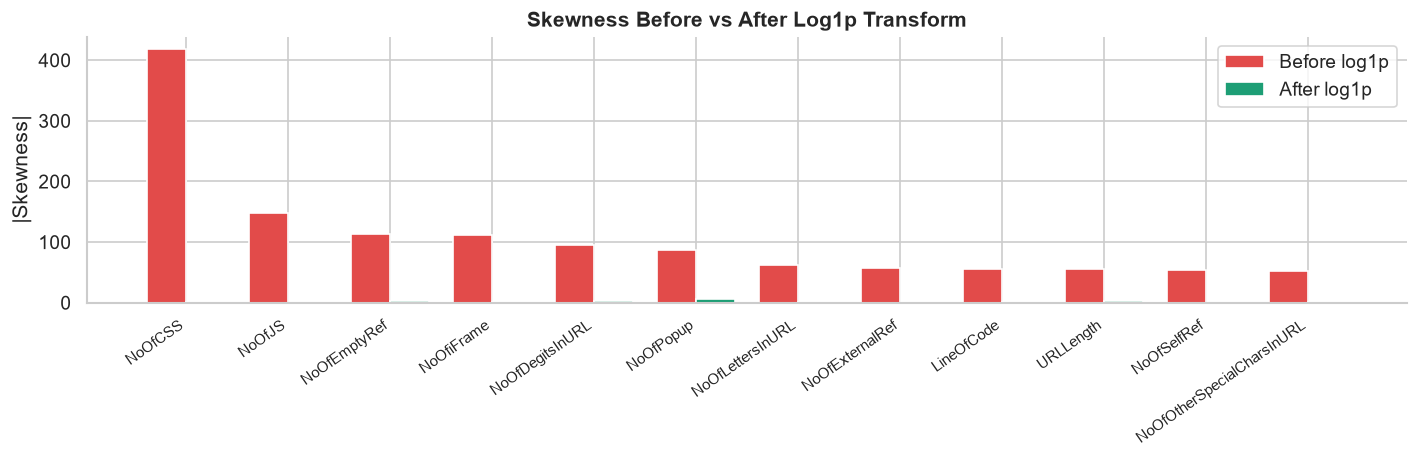

In [9]:
# Before/after skewness bar chart
sr = skew_report.sort_values('skewness_before', ascending=False).head(12)
x  = np.arange(len(sr))
w  = 0.38
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - w/2, sr['skewness_before'].abs(), width=w,
       label='Before log1p', color='#E24B4A', edgecolor='white')
ax.bar(x + w/2, sr['skewness_after'].abs(),  width=w,
       label='After log1p',  color='#1D9E75', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(sr['feature'], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('|Skewness|')
ax.set_title('Skewness Before vs After Log1p Transform', fontweight='600')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'skewness_correction.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Phase C — Outlier Clipping (P99.9)

In [10]:
clipper = OutlierClipper(quantile=0.999)
clipper.fit(X_B_train_raw.select_dtypes(include=[np.number]))

thresh_df = clipper.get_thresholds_df()
thresh_df.to_csv(REPORTS_DIR / 'outlier_thresholds.csv', index=False)

# Show high-impact features (where P99.9 << max)
for feat in ['LineOfCode','NoOfCSS','LargestLineLength','NoOfImage','URLLength']:
    if feat in X_B_train_raw.columns:
        max_val  = float(X_B_train_raw[feat].max())
        thresh   = thresh_df.loc[thresh_df['feature']==feat,'p999_threshold'].values
        t        = thresh[0] if len(thresh) else float('nan')
        print(f'  {feat:<35} max={max_val:>12,.1f}  P99.9={t:>10,.1f}')


2026-06-17 20:27:03 | INFO     | src.features.preprocessing               | OutlierClipper fitted: P99.9 thresholds computed for 48 numeric columns


  LineOfCode                          max=   442,666.0  P99.9=  28,381.4
  NoOfCSS                             max=    35,820.0  P99.9=     107.0
  LargestLineLength                   max=13,975,732.0  P99.9=1,420,638.4
  NoOfImage                           max=     8,956.0  P99.9=     912.8
  URLLength                           max=     6,097.0  P99.9=     464.0


## 7. Phase D — RobustScaler

In [11]:
# Show which features will be scaled vs left unchanged
scaler = RobustScalerTransformer()
scaler.fit(X_B_train_raw)

print(f'Features to scale  : {len(scaler.scale_cols_)}')
print(f'Binary (unchanged) : {len(BINARY_FEATURES)}')
print(f'\nSample scaling params (first 10):')
scale_report = scaler.get_scaling_report()
scale_report.to_csv(REPORTS_DIR / 'scaling_report.csv', index=False)
display(scale_report[scale_report['scaled']==True].head(10))


2026-06-17 20:27:03 | INFO     | src.features.preprocessing               | RobustScalerTransformer fitted: 29 columns scaled, 20 binary columns unchanged


Features to scale  : 29
Binary (unchanged) : 20

Sample scaling params (first 10):


,feature,center_median,scale_iqr,scaled
0,CharContinuationRate,1.000,0.320,True
1,DegitRatioInURL,0.000,1.000,True
2,DomainLength,20.000,8.000,True
3,DomainTitleMatchScore,75.000,100.000,True
4,LargestLineLength,1091.000,7847.000,True
5,LetterRatioInURL,0.519,0.159,True
6,LineOfCode,432.000,1261.000,True
7,NoOfAmpersandInURL,0.000,1.000,True
8,NoOfCSS,2.000,8.000,True
9,NoOfDegitsInURL,0.000,1.000,True


## 8. Phase E — Feature Engineering (7 derived features)

In [12]:
eng = FeatureEngineer()
eng.fit(X_B_train_raw)
X_B_engineered = eng.transform(X_B_train_raw)

print('New engineered features:')
for feat in ENGINEERED_FEATURE_NAMES:
    s = X_B_engineered[feat]
    print(f'  {feat:<28} mean={s.mean():.4f}  std={s.std():.4f}  nunique={s.nunique()}')

print(f'\nShape before: {X_B_train_raw.shape}')
print(f'Shape after:  {X_B_engineered.shape}')


2026-06-17 20:27:03 | INFO     | src.features.engineering                 | FeatureEngineer fitted (no-op): input has 49 columns


New engineered features:
  ContentComplexityScore       mean=2.4847  std=1.9058  nunique=938
  FormDangerIndex              mean=0.5239  std=0.7012  nunique=4
  TrustBadgeScore              mean=1.5747  std=1.4140  nunique=5
  RedirectActivity             mean=0.1730  std=0.4719  nunique=3
  ExternalRefDensity           mean=2.1109  std=39.0422  nunique=23219
  TLD_is_gov_edu               mean=0.0144  std=0.1193  nunique=2
  SubdomainRatio               mean=0.0546  std=0.0268  nunique=243

Shape before: (188296, 49)
Shape after:  (188296, 56)


In [13]:
# Validate engineered features
eng.validate_output(X_B_engineered)
print('Validation PASSED ✓')


2026-06-17 20:27:03 | INFO     | src.features.engineering                 | FeatureEngineer output validation PASSED ✓


Validation PASSED ✓


In [14]:
# Save engineered features report
from src.features.pipeline_builder import _save_engineered_report
X_B_with_label = X_B_engineered.copy()
X_B_with_label['label'] = y_train['label'].values
_save_engineered_report(split_results['track_B_train'], X_B_with_label, REPORTS_DIR)

# Correlation of engineered features with label
eng_corr = X_B_with_label[ENGINEERED_FEATURE_NAMES + ['label']].corr()['label']
print('Correlation of engineered features with label:')
print(eng_corr.drop('label').sort_values(key=abs, ascending=False).to_string())


2026-06-17 20:27:04 | INFO     | src.features.pipeline_builder            | Saved: engineered_features_report.csv  (7 rows)


Correlation of engineered features with label:
ContentComplexityScore    0.895744
TrustBadgeScore           0.830086
FormDangerIndex           0.459812
SubdomainRatio            0.243878
TLD_is_gov_edu            0.104166
RedirectActivity         -0.062884
ExternalRefDensity        0.027943


## 9. Phase F & G — Pipeline Construction & Serialisation

In [15]:
# Build and inspect pipeline structure
pipeline_A = build_pipeline('A')
pipeline_B = build_pipeline('B')

print('Track A pipeline steps:')
for name, step in pipeline_A.steps:
    print(f'  {name:<15} {type(step).__name__}')


2026-06-17 20:27:04 | INFO     | src.features.pipeline_builder            | Built pipeline for Track A with steps: ['engineer', 'tld_enc', 'clipper', 'log1p', 'scaler']
2026-06-17 20:27:04 | INFO     | src.features.pipeline_builder            | Built pipeline for Track B with steps: ['engineer', 'tld_enc', 'clipper', 'log1p', 'scaler']


Track A pipeline steps:
  engineer        FeatureEngineer
  tld_enc         TLDFrequencyEncoder
  clipper         OutlierClipper
  log1p           Log1pTransformer
  scaler          RobustScalerTransformer


In [16]:
# Run the full preprocessing pipeline for both tracks
pp_results = run_full_preprocessing(
    split_results    = split_results,
    preprocessor_dir = PREPROCESSOR_DIR,
    processed_dir    = PROCESSED_DIR,
    reports_dir      = REPORTS_DIR,
)

X_train_A = pp_results['X_train_A']
X_test_A  = pp_results['X_test_A']
X_train_B = pp_results['X_train_B']
X_test_B  = pp_results['X_test_B']

print(f'Track A — X_train: {X_train_A.shape}  X_test: {X_test_A.shape}')
print(f'Track B — X_train: {X_train_B.shape}  X_test: {X_test_B.shape}')


2026-06-17 20:27:04 | INFO     | src.features.pipeline_builder            | =======================================================
2026-06-17 20:27:04 | INFO     | src.features.pipeline_builder            | M3.1 — FULL PREPROCESSING PIPELINE
2026-06-17 20:27:04 | INFO     | src.features.pipeline_builder            | =======================================================
2026-06-17 20:27:04 | INFO     | src.features.pipeline_builder            | 
────────────────────────────────────────
2026-06-17 20:27:04 | INFO     | src.features.pipeline_builder            | TRACK A
2026-06-17 20:27:04 | INFO     | src.features.pipeline_builder            | ────────────────────────────────────────
2026-06-17 20:27:04 | INFO     | src.features.pipeline_builder            | Built pipeline for Track A with steps: ['engineer', 'tld_enc', 'clipper', 'log1p', 'scaler']
2026-06-17 20:27:04 | INFO     | src.features.pipeline_builder            | Fitting pipeline on 188,296 training rows × 50 columns …
2026

Track A — X_train: (188296, 57)  X_test: (47074, 57)
Track B — X_train: (188296, 56)  X_test: (47074, 56)


## 10. Phase H — Full Validation

In [17]:
val_A = pp_results['validation_A']
val_B = pp_results['validation_B']

print('=== Track A Validation ===')
for check in val_A['results']:
    sym = '✓' if check['status']=='PASS' else '✗'
    print(f'  {sym}  {check["check"]:<35}  {check["status"]}')

print(f'\n=== Track B Validation ===')
for check in val_B['results']:
    sym = '✓' if check['status']=='PASS' else '✗'
    print(f'  {sym}  {check["check"]:<35}  {check["status"]}')

assert val_A['all_passed'], 'Track A validation FAILED'
assert val_B['all_passed'], 'Track B validation FAILED'
print('\nALL VALIDATION CHECKS PASSED ✓')


=== Track A Validation ===
  ✓  output_shape                         PASS
  ✓  no_missing_values                    PASS
  ✓  feature_types                        PASS
  ✓  feature_count                        PASS
  ✓  tld_encoded                          PASS
  ✓  log1p_applied                        PASS
  ✓  engineered_features                  PASS
  ✓  binary_unchanged                     PASS

=== Track B Validation ===
  ✓  output_shape                         PASS
  ✓  no_missing_values                    PASS
  ✓  feature_types                        PASS
  ✓  feature_count                        PASS
  ✓  tld_encoded                          PASS
  ✓  log1p_applied                        PASS
  ✓  engineered_features                  PASS
  ✓  binary_unchanged                     PASS

ALL VALIDATION CHECKS PASSED ✓


## 11. Serialisation Verification

In [18]:
# Verify pipelines can be loaded and produce identical output
from src.features.pipeline_builder import load_pipeline, transform_data

for track, X_test in [('A', X_test_A), ('B', X_test_B)]:
    pkl_path    = PREPROCESSOR_DIR / f'preprocessor_{track}.pkl'
    pipe_loaded = load_pipeline(pkl_path)

    X_reloaded  = transform_data(pipe_loaded,
                                 split_results[f'track_{track}_test']
                                 .drop(columns=['label'], errors='ignore'))

    # Verify numerical identity
    max_diff = (X_test.values.astype(float) - X_reloaded.values.astype(float)).max()
    assert abs(max_diff) < 1e-9, f'Track {track}: loaded pipeline differs!'
    print(f'Track {track}: serialisation round-trip PASSED ✓  ')


2026-06-17 20:27:39 | INFO     | src.features.pipeline_builder            | Pipeline loaded ← C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\preprocessors\preprocessor_A.pkl
2026-06-17 20:27:40 | INFO     | src.features.pipeline_builder            | Pipeline loaded ← C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\preprocessors\preprocessor_B.pkl


Track A: serialisation round-trip PASSED ✓  
Track B: serialisation round-trip PASSED ✓  


## 12. Artifact Summary

In [19]:
print('=== M3.1 OUTPUT ARTIFACTS ===')

artifacts = [
    ('outputs/preprocessors/preprocessor_A.pkl', 'Fitted Track A pipeline'),
    ('outputs/preprocessors/preprocessor_B.pkl', 'Fitted Track B pipeline'),
    ('data/processed/track_A/X_train.csv',       'Preprocessed Track A train'),
    ('data/processed/track_A/X_test.csv',        'Preprocessed Track A test'),
    ('data/processed/track_B/X_train.csv',       'Preprocessed Track B train'),
    ('data/processed/track_B/X_test.csv',        'Preprocessed Track B test'),
    ('data/processed/y_train.csv',               'Shared label train'),
    ('data/processed/y_test.csv',                'Shared label test'),
    ('outputs/reports/tld_encoding_report.csv',  'TLD encoding mapping'),
    ('outputs/reports/skewness_correction_report.csv', 'Log1p skewness report'),
    ('outputs/reports/outlier_thresholds.csv',   'P99.9 clipping thresholds'),
    ('outputs/reports/scaling_report.csv',       'RobustScaler parameters'),
    ('outputs/reports/engineered_features_report.csv', 'Engineered feature stats'),
]

import pathlib
for rel, desc in artifacts:
    p   = PROJECT_ROOT / rel
    sym = '✓' if p.exists() else '✗ MISSING'
    print(f'  {sym}  {rel:<52}  {desc}')


=== M3.1 OUTPUT ARTIFACTS ===
  ✓  outputs/preprocessors/preprocessor_A.pkl              Fitted Track A pipeline
  ✓  outputs/preprocessors/preprocessor_B.pkl              Fitted Track B pipeline
  ✓  data/processed/track_A/X_train.csv                    Preprocessed Track A train
  ✓  data/processed/track_A/X_test.csv                     Preprocessed Track A test
  ✓  data/processed/track_B/X_train.csv                    Preprocessed Track B train
  ✓  data/processed/track_B/X_test.csv                     Preprocessed Track B test
  ✓  data/processed/y_train.csv                            Shared label train
  ✓  data/processed/y_test.csv                             Shared label test
  ✓  outputs/reports/tld_encoding_report.csv               TLD encoding mapping
  ✓  outputs/reports/skewness_correction_report.csv        Log1p skewness report
  ✓  outputs/reports/outlier_thresholds.csv                P99.9 clipping thresholds
  ✓  outputs/reports/scaling_report.csv                    Ro

## 13. Conclusions

In [20]:
print('=' * 62)
print('MODULE M3.1 COMPLETE')
print('=' * 62)
print(f'  Track A X_train : {X_train_A.shape}  (57 features)')
print(f'  Track A X_test  : {X_test_A.shape}')
print(f'  Track B X_train : {X_train_B.shape}  (56 features)')
print(f'  Track B X_test  : {X_test_B.shape}')
print(f'  y_train         : {len(y_train):,} labels')
print(f'  y_test          : {len(y_test):,} labels')
print()
print('Pipeline steps:')
print('  1. FeatureEngineer        — 7 derived features added')
print('  2. TLDFrequencyEncoder    — TLD string → int rank (top-50)')
print('  3. OutlierClipper         — P99.9 capping (train-only)')
print('  4. Log1pTransformer       — 15 skewed count features')
print('  5. RobustScalerTransformer — continuous non-binary features')
print()
print('All validation checks PASSED ✓')
print('Pipelines serialised and verified ✓')
print()
print('Next: M4.1 — Model Training (6 models × 2 tracks)')


MODULE M3.1 COMPLETE
  Track A X_train : (188296, 57)  (57 features)
  Track A X_test  : (47074, 57)
  Track B X_train : (188296, 56)  (56 features)
  Track B X_test  : (47074, 56)
  y_train         : 188,296 labels
  y_test          : 47,074 labels

Pipeline steps:
  1. FeatureEngineer        — 7 derived features added
  2. TLDFrequencyEncoder    — TLD string → int rank (top-50)
  3. OutlierClipper         — P99.9 capping (train-only)
  4. Log1pTransformer       — 15 skewed count features
  5. RobustScalerTransformer — continuous non-binary features

All validation checks PASSED ✓
Pipelines serialised and verified ✓

Next: M4.1 — Model Training (6 models × 2 tracks)
